<div style="background-color: lightblue; text-align: center; padding: 20px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 24px; color: #333;">
        Проект: "Обучение с учителем: качество модели"
    </span>
</div>

<span style="background-color: #008000; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Преамбула проекта
    </span>
</span>

**Цель проекта** - разработать модель, которая позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность и, как следствие, увеличт доход Компании.  
  
  **Задачи проекта** - создать две прогнозные модели для отбора коров:  
* построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца; 
* включить в исследование дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца;  
* опираясь на данные модели и данные о прибыльности клиентов, необходимо сегментировать покупателей и разработать для них персонализированные предложения.

<span style="background-color: #008000; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Структура проекта
    </span>
</span>

**Данный проект состоит из следующийх этапов:**  
1.   Подготовка рабочего пространства
2.   Предобработка данных
3.   Исследовательский анализ данных
4. Объединение таблиц
5.   Корреляционный анализ
6.   Использование пайплайнов
7.   Анализ важности признаков 
8.   Сегментация покупателей
9. Итоговые выводы

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 1. Подготовка рабочего пространства. Загрузка данных
    </span>
</span>

In [1]:
# необходимые импорты библиотек:
%pip install phik -q
%pip install shap -q
%pip install -U scikit-learn -q
%pip install tabulate -q

import phik
import shap
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
from tabulate import tabulate

from phik import report
from scipy.stats import binom
from scipy.stats import norm
from sklearn.model_selection import (train_test_split, 
                                     GridSearchCV, 
                                     RandomizedSearchCV)

from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             precision_score, recall_score, 
                             roc_auc_score, roc_curve)
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, LabelEncoder, 
                                   OneHotEncoder, OrdinalEncoder, 
                                   RobustScaler, StandardScaler)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


C:\Users\seriy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
RANDOM_STATE = 42

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# импорт датасетов

# 1) данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении:
market_file = pd.read_csv('/datasets/market_file.csv', sep=',', 
                          decimal='.', encoding='utf-8')

# 2) данные о выручке, которую получает магазин с покупателя
# учитывает совокупные траты за период взаимодействия с сайтом:
market_money = pd.read_csv('/datasets/market_money.csv', sep=',', 
                           decimal='.', encoding='utf-8')

# 3) данные о времени, которое покупатель провёл на сайте в течение периода
# время указано в минутах:
market_time = pd.read_csv('/datasets/market_time.csv', sep=',', 
                           decimal='.', encoding='utf-8')

# 4) данные о среднемесячной прибыли продавца за последние 3 месяца
# учитывает прибыль магазина от продаж каждому покупателю:
money = pd.read_csv('/datasets/money.csv', sep=';', 
                    decimal=',', encoding='utf-8')

In [ ]:
# создадим копии датасетов:
market_file_copy = market_file.copy()
market_money_copy = market_money.copy()
market_time_copy = market_time.copy()
money_copy = money.copy()

**Проверим, что данные в таблицах соответствуют описанию:**

In [ ]:
market_file.head(1)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5


In [ ]:
market_money.head(1)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0


In [ ]:
market_time.head(1)

,id,Период,минут
0,215348,текущий_месяц,14


In [ ]:
money.head(1)

,id,Прибыль
0,215348,0.98


**Итог:** данные выглядят корректно. Разделители приведены к единому виду

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 2. Предобработка данных
    </span>
</span>

**Цель:** провести предобработку, подготовить данные для дальнейшей корректной работы

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_file.csv'
    </span>
</span>

In [ ]:
# проверим основную информацию:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Пропусков не наблюдается.  
Видна разобщенность: разделение слов пробелами и подчеркиваниями.

* **Приведем наименования данных к нижнему регистру:**

In [ ]:
market_file.columns = market_file.columns.str.lower()
market_file.columns = market_file.columns.str.replace('_', ' ')
market_file = market_file.applymap(lambda x: x.lower() if isinstance(x, str) else x)

In [ ]:
market_file.head(1)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
0,215348,снизилась,премиум,да,3.4,5,121,0.0,товары для детей,6,2,1,5


Данные приведены к нижнему регистру, подчеркивания заменены на пробелы.

* **Проверим на дубликаты:**

In [ ]:
market_file.duplicated().sum()

0

Дубликатов не обнаружено

* **Проверим на неявные дубликаты категориальные признаки:**

In [ ]:
market_file['покупательская активность'].unique()

array(['снизилась', 'прежний уровень'], dtype=object)

In [ ]:
market_file['тип сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

В некоторых названиях наблюдается задвоение букв. 

In [ ]:
market_file['разрешить сообщать'].unique()

array(['да', 'нет'], dtype=object)

In [ ]:
market_file['популярная категория'].unique()

array(['товары для детей', 'домашний текстиль', 'косметика и аксесуары',
       'техника для красоты и здоровья', 'кухонная посуда',
       'мелкая бытовая техника и электроника'], dtype=object)

Орфографическая ошибка в 'косметика и аксесуары'. Пропущена буква 'C' в слове 'аксессуары'

* **Исправим найденные недочеты (неявные дубликаты):**

In [ ]:
market_file['тип сервиса'] = (market_file[
    'тип сервиса'].replace(['стандартт'],'стандарт')
)

In [ ]:
market_file['популярная категория'] = (market_file[
    'популярная категория'].replace(
    ['косметика и аксесуары'],'косметика и аксессуары')
)

In [ ]:
market_file['тип сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [ ]:
market_file['популярная категория'].unique()

array(['товары для детей', 'домашний текстиль', 'косметика и аксессуары',
       'техника для красоты и здоровья', 'кухонная посуда',
       'мелкая бытовая техника и электроника'], dtype=object)

Недочеты исправлены, данные приведены в порядок.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_money.csv'
    </span>
</span>

In [ ]:
# проверим основную информацию:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


* **Приведем наименования данных к нижнему регистру:**

In [ ]:
market_money.columns = market_money.columns.str.lower()
market_money['период'] = market_money['период'].str.replace('_', ' ', regex=False)

In [ ]:
market_money.head(1)

,id,период,выручка
0,215348,препредыдущий месяц,0.0


Наименования приведены к нижнему регистру.

* **Проверим на дубликаты:**

In [ ]:
market_money.duplicated().sum()

0

Явных дубликатов - 0

* **Проверим на неявные дубликаты категориальные признаки:**

In [ ]:
market_money['период'].unique()

array(['препредыдущий месяц', 'текущий месяц', 'предыдущий месяц'],
      dtype=object)

Видим наличие ***'препредыдущий месяц'***. Это может быть опечаткой. Однако, по условиям задачи нам необходимо брать в расчет клиентов с покупательной активностью не меньше трех месяцев. Переименуем в соответствии с правилами русского языка на 'позапрошлый месяц'

* **Исправим найденные недочеты (неявные дубликаты):**

In [ ]:
market_money['период'] = (market_money[
    'период'].replace(['препредыдущий месяц'],'позапрошлый месяц')
)

In [ ]:
market_money['период'].unique()

array(['позапрошлый месяц', 'текущий месяц', 'предыдущий месяц'],
      dtype=object)

Неявный дубликат удален.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_time.csv'
    </span>
</span>

In [ ]:
# проверим основную информацию:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Пропусков не наблюдается.

Несовпадающий регистр, подчеркивание вместо пробела.

* **Приведем наименования данных к нижнему регистру:**

In [ ]:
market_time.columns = market_time.columns.str.lower()
market_time['период'] = market_time['период'].str.replace('_', ' ', regex=False)

In [ ]:
market_time.head(1)

,id,период,минут
0,215348,текущий месяц,14


Данные приведены к общему единому стилю оформления

* **Проверим на дубликаты:**

In [ ]:
market_time.duplicated().sum()

0

Дубликатов - 0

* **Проверим на неявные дубликаты категориальные признаки:**

In [ ]:
market_time['период'].unique()

array(['текущий месяц', 'предыдцщий месяц'], dtype=object)

Обнаружена орфографическая опечатка в одном из признаков. Дублирующее значение не создает, но избавимся от опечатки

* **Исправим опечатку:**

In [ ]:
market_time['период'] = (market_time[
    'период'].replace(['предыдцщий месяц'],'предыдущий месяц')
)

In [ ]:
market_time['период'].unique()

array(['текущий месяц', 'предыдущий месяц'], dtype=object)

Ошибка исправлена. Наименования корректные

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'money.csv'
    </span>
</span>

In [ ]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Пропусков не наблюдается

* **Приведем наименования столбца к нижнему регистру:**

In [ ]:
money.columns = money.columns.str.lower()

In [ ]:
money.head(1)

,id,прибыль
0,215348,0.98


Задача выполнена. Наименования столбцов приведены к нижнему регистру.

* **Проверим на дубликаты:**

In [ ]:
money.duplicated().sum()

0

Дубликатов - 0

* **Проверим на неявные дубликаты категориальные признаки:**

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 2. Предоботка данных
    </span>
</span>

Нами были проанализированы 4 датасета с задачей найти в них ошибки и недочеты, которые могли бы исказить и повлиять на результаты нашей работы в дальнейшем.  
Так, была обнаружена несогласованность между датасетами:  
* написание категорий и их признаков буквами разного регистра;  
* разделение слов пробелами и подчеркиваниями;  
* неявные дубликаты, вызванные, по всей видимости, опечатками;  
* орфографически неправильное написание некоторых наименований.  

В результате нашей работы 4 исследуемых датасета были приведены к единому стилю оформления - нижний регистр, написание через пробелы, исправлены орфографические ошибки и приведены к нормам соответствия русскому языку.  
  
  Явных дубликатов не было обнаружено

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 3. Исследовательский анализ
    </span>
</span>

**Цель:** изучить подготовленные ранее данные из четырех датасетов, чтобы впоследствии отобрать клиентов, которые что-либо покупали за период не менее трёх месяцев.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_file.csv'
    </span>
</span>

Проведем анализ датасета 'market_file.csv'. Изучим числовые данные методом describe(), затем их визуализируем.

In [ ]:
market_file.describe()

,id,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


Пока что исходя из результатов таблицы нельзя сказать, что здесь есть что-то неординарное.  Визуализируем данные.

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Числовые признаки
    </span>
</div>

* **маркетинговая активность за 6 месяцев:**

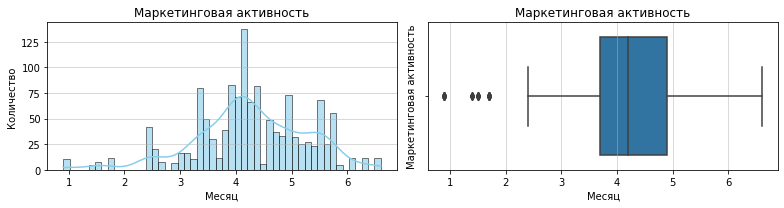

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

# гистограмма:
sns.histplot(data=market_file, 
             x='маркет актив 6 мес', 
             bins=50, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Маркетинговая активность')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_file['маркет актив 6 мес'], ax=axes[1])
axes[1].set_title('Маркетинговая активность')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Маркетинговая активность')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Наблюдаем несколько сильно заметных пиков в гистограмме на уровнях ~: 2.4, 3.4, 4.2, 5, 5.8.  
Наибольшее количество активностей приходится на ~ первую декаду четвертого месяца.  
Имеется неравномерность в активностсях в период до двух месяцев. В некоторые короткие их количество сведено к минимуму.  
К 2.5 месяцам активность резко увеличивается (по сравнению с предыдущими месяцами). Затем так же резко идет на спат.  
Маркетинговая активность скачкообразная, с выраженными всплесками. Стоит отметить также, что по прошествии 6 месяцев наблюдается резкий спад по количеству, но при этом на протяжении нескольких декад он равномерный (равномерно низкий).  


* **маркетинговая активность за текущий месяц:**

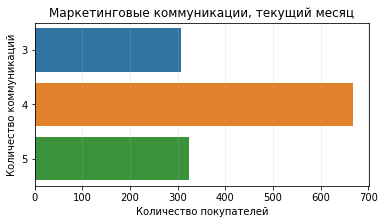

In [ ]:
plt.figure(figsize=(6, 3))
sns.countplot(y='маркет актив тек мес', 
              data=market_file
)
plt.title('Маркетинговые коммуникации, текущий месяц')
plt.xlabel('Количество покупателей')
plt.ylabel('Количество коммуникаций')
plt.grid(axis='x', 
         alpha=0.3, 
         linestyle='-', 
         linewidth=0.7)
plt.show()

Мы видим, что 3 и 5 коммуникаций примерно равны по количеству покупателей, с небольшим перекосом в сторону пятой. Лидером по активности были 4 коммуникации, затрагивающих почти 700 покупателей.

* **дни после регистрации:**

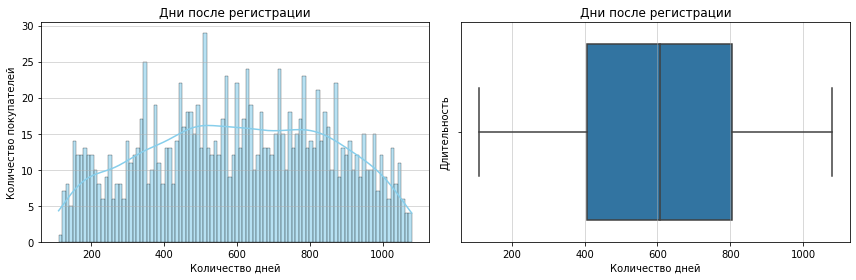

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# гистограмма:
sns.histplot(data=market_file, 
             x='длительность', 
             bins=100, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Дни после регистрации')
axes[0].set_xlabel('Количество дней')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_file['длительность'], ax=axes[1])
axes[1].set_title('Дни после регистрации')
axes[1].set_xlabel('Количество дней')
axes[1].set_ylabel('Длительность')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Распределение близко к нормальному, с центром в районе 600 дней. Минимум находится на уровне ~ 100 дней. При этом наблюдаются пользователи, у которых активность была спустя 1000 дней после регистрации, а также пользователи, у которых активность менее 200 дней.
Наблюдаются много отчетливых пиков. В целом, основной пул пользователей лежит в диапазоне от ~430 до ~840 дней.

* **среднемесячная доля покупок по акции:**

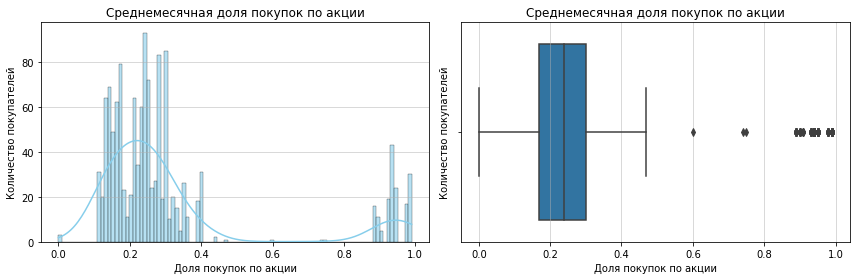

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# гистограмма:
sns.histplot(data=market_file, 
             x='акционные покупки', 
             bins=100, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Среднемесячная доля покупок по акции')
axes[0].set_xlabel('Доля покупок по акции')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_file['акционные покупки'], ax=axes[1])
axes[1].set_title('Среднемесячная доля покупок по акции')
axes[1].set_xlabel('Доля покупок по акции')
axes[1].set_ylabel('Количество покупателей')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Наблюдается ассимитричное распределение, большой пик в левой части. В левой части можно наблюдать 2 группы:  
* группа 1 - в диапазоне 0.1-0.2;
* группа 2 - диапазоне 0.2 - 0.4.  
"Обвал" Значений на диапазоне ~0.43 - 0.87.  
В правой части наблюдается небольшая третья группа, диапазон ~0.88 - 0.99  
Много правосторонних выбросов. В левой части выбросов практически нет.

* **Средний показатель просмотра категорий за один визит и неоплаченные товары за квартал:**

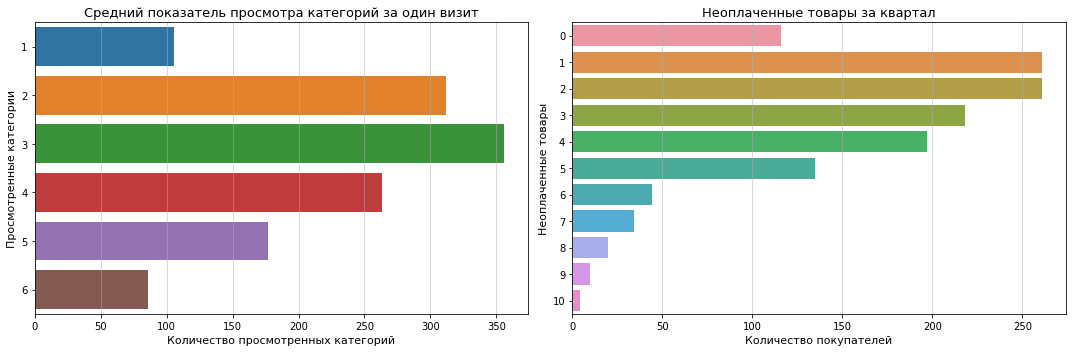

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# просмотр категорий
sns.countplot(y='средний просмотр категорий за визит', 
              data=market_file, 
              ax=axes[0])
axes[0].set_title('Средний показатель просмотра категорий за один визит', 
                  fontsize=13)
axes[0].set_xlabel('Количество просмотренных категорий', 
                   fontsize=11)
axes[0].set_ylabel('Просмотренные категории', 
                   fontsize=11)
axes[0].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)

# неоплаченные товары
sns.countplot(y='неоплаченные продукты штук квартал', 
              data=market_file, 
              ax=axes[1])
axes[1].set_title('Неоплаченные товары за квартал', 
                  fontsize=13)
axes[1].set_xlabel('Количество покупателей', 
                   fontsize=11)
axes[1].set_ylabel('Неоплаченные товары', 
                   fontsize=11)
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)

plt.tight_layout()
plt.show()

**Средний показатель просмотра категорий за один визит**  
Всего 6 категорий. Наибольшее количество просмотров у категорий 3, 2 и 4 (в порядке убывания).  
  
  **Неоплаченные товары за квартал**  
  1-2 товара - самое популярное количество неоплаченных товаров у покупателей - ~260 покупателей. Есть категория покупателей, у которых и вовсе 0 неоплаченных товаров.  
  При этом наблюдается закономерность - при увеличении числа товаров снижается и количество покупателей, которые делают такие покупки.

* **Сбои при посещении сайта и количество просмотренных страниц за визит за последние 3 месяца:**

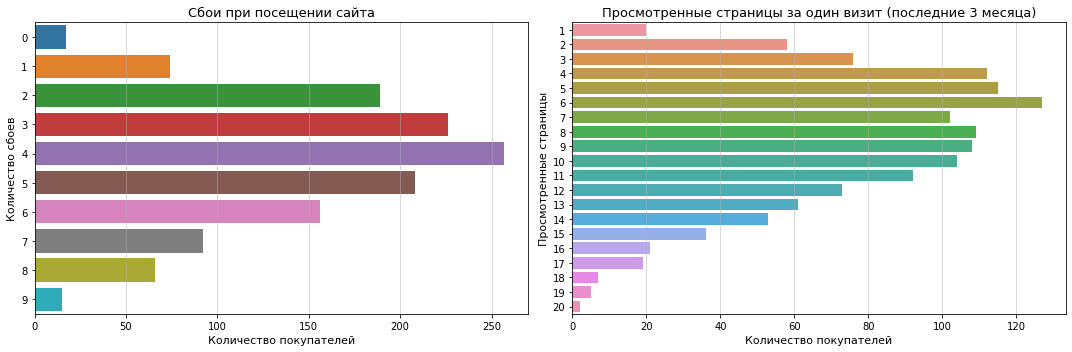

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ошибки сервиса:
sns.countplot(y='ошибка сервиса', 
              data=market_file, 
              ax=axes[0])
axes[0].set_title('Сбои при посещении сайта', 
                  fontsize=13)
axes[0].set_xlabel('Количество покупателей', 
                   fontsize=11)
axes[0].set_ylabel('Количество сбоев', 
                   fontsize=11)
axes[0].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)

# просмотренные страницы за визит:
sns.countplot(y='страниц за визит', 
              data=market_file, 
              ax=axes[1])
axes[1].set_title('Просмотренные страницы за один визит (последние 3 месяца)', 
                  fontsize=13)
axes[1].set_xlabel('Количество покупателей', 
                   fontsize=11)
axes[1].set_ylabel('Просмотренные страницы', 
                   fontsize=11)
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)

plt.tight_layout()
plt.show()

* **Сбои при посещении сайта**  
Количество сбоев лежит в диапазоне от 0 до 9. Стоит отметить, что по количеству покупателей, столкнувшихся со сбоями при посещении сайта, 0 и 9 ошибок имеют практически равное количество.  
Однако 9 ошибок - это крайне много, хоть и составляет малую часть от общих сбоев.  
Важнее обратить внимание на то, что с 0 ошибок сталкивается малое количество пользователей. Таким образом, можно сказать, что практически каждый пользователь при посещении сайта сталкивается с той или иной проблемой, что напрямую может сказываться на финансовые результаты.  
  
  **Топ-3 количества ошибок** - это:  
* 4 ошибки - чуть больше 250 пользователей;  
* 3 ошибки - ~225 покупателей;  
* 5 ошибок - ~210 покупателей.  
В целом, достаточно большое количество ошибок.
  
  
* **Просмотренные страницы за один визит (последние 3 месяца)**  
На представленном графике видно, что в основном люди посещают за один визит от 4 до 10 страниц. Далее с увеличением количества просмотренных страниц, количество покупателей снижается. Есть рекордсмены, которые просмотрели 20 страниц за один визит. Таких пользователей меньшинство.

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Категориальные признаки
    </span>
</div>

Визуализируем категориальные признаки и их соотношение через диаграммы

* **Активность покупателей и Тип сервиса:**

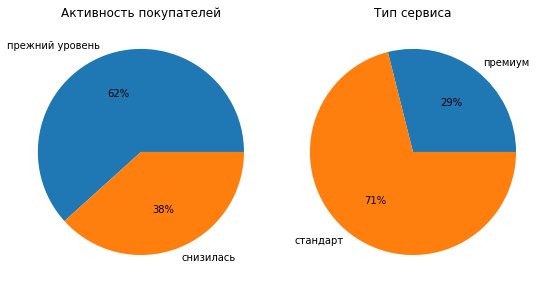

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4)) 

# активность покупателей:
pivot_table1 = market_file.pivot_table(
    index='покупательская активность',
    values='id',
    aggfunc='count'
)
pivot_table1.plot.pie(
    y='id',
    autopct='%1.0f%%',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Активность покупателей')
axes[0].set_ylabel('')

# соотношение по типу сервиса:
pivot_table2 = market_file.pivot_table(
    index='тип сервиса',
    values='id',
    aggfunc='count'
)
pivot_table2.plot.pie(
    y='id',
    autopct='%1.0f%%',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Тип сервиса')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()

* **покупательская активность** - по условию, является целевым признаком.  
Наблюдается перекос с сторону снижения активности покупателей;  
  
* **тип сервиса** - с большим перевесом пользователи представлены типом сервиса "стандарт" - 71%

* **Разрешения на сообщения и Популярные категории:**

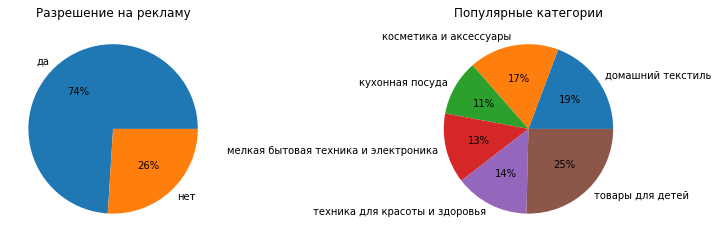

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6)) 

# разрешение на сообщения:
pivot_table1 = market_file.pivot_table(
    index='разрешить сообщать',
    values='id',
    aggfunc='count'
)
pivot_table1.plot.pie(
    y='id',
    autopct='%1.0f%%',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Разрешение на рекламу')
axes[0].set_ylabel('')

# популярные категории:
pivot_table2 = market_file.pivot_table(
    index='популярная категория',
    values='id',
    aggfunc='count'
)
pivot_table2.plot.pie(
    y='id',
    autopct='%1.0f%%',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Популярные категории')
axes[1].set_ylabel('')


plt.tight_layout()
plt.show()

**Разрешения на сообщения:**  как видим, чуть больше четверти покупателей не давали согласия на отправку сообщений со стороны Компании.  
  
  
**Популярные категории:** самая популярная категория - товары для детей, составляет четверть от общего числа;  
Вторая и третья по популярности категории - домашний текстиль и косметика и аксессуары;  
Остальные категории распределены практически поровну.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_money.csv'
    </span>
</span>

Согласно тех. заданию, нам необходимо отобрать покупателей с активностью не менее 3 месяцев.  
Отфильтруем требуемое зачение в датасете

In [ ]:
market_money = market_money[market_money.id.isin(
        market_money.query(
            'выручка==0')['id'].unique())==False]

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Числовые признаки
    </span>
</div>

* **Выручка за период:**

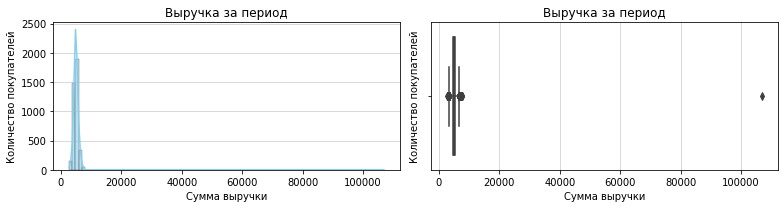

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

# гистограмма:
sns.histplot(data=market_money, 
             x='выручка', 
             bins=100, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Выручка за период')
axes[0].set_xlabel('Сумма выручки')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_money['выручка'], ax=axes[1])
axes[1].set_title('Выручка за период')
axes[1].set_xlabel('Сумма выручки')
axes[1].set_ylabel('Количество покупателей')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Исходя из полученных данных, сумма выручки за период на пользователя не превышает 10000.  
При этом наблюдается выброс - свыше 100000

In [ ]:
# проверим выброс:
market_money.sort_values(by='выручка', ascending=False).head(2)

,id,период,выручка
98,215380,текущий месяц,106862.2
435,215493,текущий месяц,7799.4


У пользователя в строке 99 наблюдается аномально высокий показатель по выручке - 106862. У второго по величине выручки пользователя данный показатель гораздо меньше - всего лишь 7799.4. Огромный разрыв.   
  
  Возможно, техническая ошибка или действительно крупные покупки были за период. Так или иначе, это всего лишь один показатель в таблице, потому можно удалить, чтобы не влиял на наши результаты исследования в дальнейшем.

In [ ]:
# оставляем в таблице значения выручки меньше 7800:
market_money = market_money[market_money['выручка'] < 7800]

Обновим нашу визуализацию

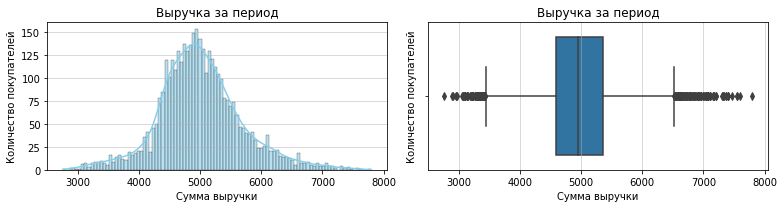

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

# гистограмма:
sns.histplot(data=market_money, 
             x='выручка', 
             bins=100, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Выручка за период')
axes[0].set_xlabel('Сумма выручки')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_money['выручка'], ax=axes[1])
axes[1].set_title('Выручка за период')
axes[1].set_xlabel('Сумма выручки')
axes[1].set_ylabel('Количество покупателей')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

За счет того, что избавились от выброса, удалось получить улучшенное представление по анализу.

Средний показатель по сумме выручки - 5000.  
Общий разброс суммы выручки колеблется от чуть меньше 3000 до чуть меньше 7800.  
Хвост смещен вправо.  
Ящик с усами показывает много выбросов справа, начинаются с ~7000. 

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Категориальные признаки
    </span>
</div>

* **Выручка по периодам:**

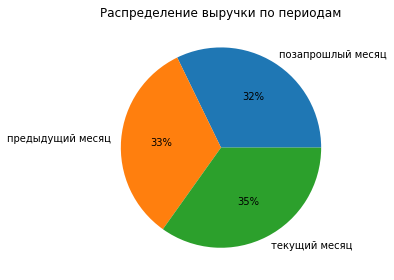

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# Создаем сводную таблицу
pivot_table = market_money.pivot_table(
    index='период',
    values='выручка',
    aggfunc='sum'
)

# Строим круговую диаграмму
pivot_table.plot.pie(
    y='выручка',
    autopct='%1.0f%%',
    legend=False,
    ax=ax
)

ax.set_title('Распределение выручки по периодам')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

Исходя из результатов, распределение выручки по месяцам примерно одинаковое, с той лишь разницей, что текущий месяц еще не закончен, соответственно результаты могут поменяться.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'market_time.csv'
    </span>
</span>

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Числовые признаки
    </span>
</div>

* **Время, проведенное пользователем на сайте:** 

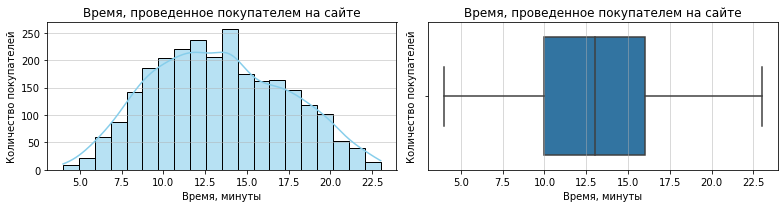

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

# гистограмма:
sns.histplot(data=market_time, 
             x='минут', 
             bins=20, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Время, проведенное покупателем на сайте')
axes[0].set_xlabel('Время, минуты')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=market_time['минут'], ax=axes[1])
axes[1].set_title('Время, проведенное покупателем на сайте')
axes[1].set_xlabel('Время, минуты')
axes[1].set_ylabel('Количество покупателей')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Распределение проведенного на сайте ближе к нормальному, с небольшой ассиметрией вправо.  
Наблюдается пиковое значение на уровне 14 минут. С 15 минут наблюдается резкое снижение количества покупателей.  
Можно отметить что основная часть пользователей тратит на сайте 10-15 минут.

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Категориальные признаки
    </span>
</div>

* **Время, проведенное пользователем на сайте за периоды:** 

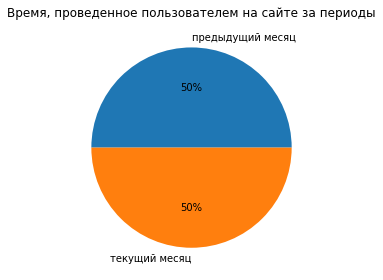

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# Создаем сводную таблицу:
pivot_table = market_time.pivot_table(
    index='период',
    values='id',
    aggfunc='count'
)

# Строим круговую диаграмму
pivot_table.plot.pie(
    y='id', 
    autopct='%1.0f%%',
    legend=False,
    ax=ax
)

# Настраиваем заголовок
ax.set_title('Время, проведенное пользователем на сайте за периоды')
ax.set_ylabel('')  # Убираем метку оси Y

plt.tight_layout()
plt.show()

Время за периоды распределилось поровну.

<span style="background-color: #8FBC8F; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Датасет 'money.csv'
    </span>
</span>

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Числовые признаки
    </span>
</div>

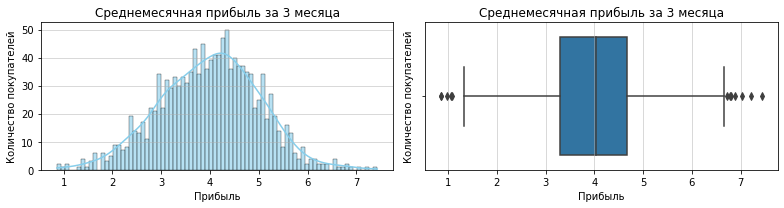

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

# гистограмма:
sns.histplot(data=money, 
             x='прибыль', 
             bins=80, 
             kde=True, 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black',
             ax=axes[0]
)
axes[0].set_title('Среднемесячная прибыль за 3 месяца')
axes[0].set_xlabel('Прибыль')
axes[0].set_ylabel('Количество покупателей')
axes[0].grid(axis='y', 
             alpha=0.6, 
             linestyle='-'
)
# boxplot
sns.boxplot(x=money['прибыль'], ax=axes[1])
axes[1].set_title('Среднемесячная прибыль за 3 месяца')
axes[1].set_xlabel('Прибыль')
axes[1].set_ylabel('Количество покупателей')
axes[1].grid(axis='x', 
             alpha=0.6, 
             linestyle='-'
)
plt.tight_layout()
plt.show()

Распределение ближе к нормальному.  
Хвост справа чуть длиннее.  
Имеются пиковые значения на 4.2-4.4.  
Мало покупателей с низкой или, наоборот, высокой прибылью. Основной диапазон представлен от 2 до 6 тысяч.  
Наличие выбросов слева и справа, характеризующие некоторую часть покупателей как тех, кто много купил и мало купил.

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 3. Исследовательский анализ
    </span>
</span>

Нами был проведен исследовательский анализ четырех датасетов.  
Мы рассмотрели количественные и категориальные признаки.  
  
  * Важно было учитывать пользователей, активность которых составляла последние 3 месяца. Потому был произведен отбор таких пользователей по заданному критерию.  
  * В ходе анализа так же мы наткнулись на выброс - крайне высокий показатель вырочки. Т.к. такой показатель был единичным, мы избавились от него, чтобы он не влиял на результаты.  
  * В данных прослеживаются выбросы.  Полученная выручка варьируется. В зависимости от категорий влиять на финансовые показатели может сезонность, проводимые акции и т.п.
  * Любимые категории товаров у покупателей - детские товары (25%), домашний текстиль (19%) и косметика и аксессуары (17%).  
  * 26% покупателей не получают рассылку рекламы/оповещений, т.к. не дали свое согласие;  
  * определено наличие высокого количества сбоев, с которыми сталкивается пользователь на сайте. Пользователей не сталкивающихся со сбоями практически нет, их малое количество. Сбои могут влиять на время посещения сайта - как в большую сторону (люди пытаются решить проблему и не уходят с сайта) так и в сторону уменьшения (сталкиваясь с проблемами, люди уходят).  
  * основная часть пользователей тратит на сайте 10-15 минут.  
  * что в основном покупателю посещают за один визит от 4 до 10 страниц сайта.
  

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 4. Объединение таблиц
    </span>
</span>

На данном этапе нам предстоит объединить следующие таблицы: market_file.csv, market_money.csv, market_time.csv. 
    Необходимо учитывать, что данные о выручке и времени на сайте находятся в одном столбце для всех периодов.  
    В итоговой таблице необходимо сделать отдельный столбец для каждого периода.

**1. Обработка 'market_time':**

In [ ]:
# возьмем каждый период в отдельности
# предыдущий месяц:
df_1 = market_time[market_time['период']=='предыдущий месяц'].copy()
df_1.rename(columns={'минут':'минут предыдущего месяца'},inplace=True)
df_1.drop('период', axis= 1 , inplace=True )

# текущий месяц:
df_2 = market_time[market_time['период']=='текущий месяц'].copy()
df_2.rename(columns={'минут':'минут текущего месяца'},inplace=True)
df_2.drop('период', axis= 1 , inplace=True )

df_market_time = pd.merge(df_1, df_2, on='id', sort=True)

In [ ]:
df_market_time.head(2)

,id,минут предыдущего месяца,минут текущего месяца
0,215348,13,14
1,215349,12,10


**2. Обработка 'market_money':**

In [ ]:
# текущий месяц:
df_1 = market_money[market_money['период']=='текущий месяц'].copy()
df_1.rename(columns={'выручка':'выручка предыдущего месяца'},inplace=True)
df_1.drop('период', axis= 1 , inplace=True )

# предыдущий месяц:
df_2 = market_money[market_money['период']=='предыдущий месяц'].copy()
df_2.rename(columns={'выручка':'выручка текущего месяца'},inplace=True)
df_2.drop('период', axis= 1 , inplace= True )

# позапрошлый месяц:
df_3 = market_money[market_money['период']=='позапрошлый месяц'].copy()
df_3.rename(columns={'выручка':'выручка позапрошлого месяца'},inplace=True)
df_3.drop('период', axis= 1 , inplace=True )

# объединяем:
df_market_money = pd.merge(df_1, df_2, on='id', sort=True)
df_market_money = pd.merge(df_3, df_market_money, on='id', sort=True)

In [ ]:
df_market_money.head(2)

,id,выручка позапрошлого месяца,выручка предыдущего месяца,выручка текущего месяца
0,215349,4472.0,4971.6,5216.0
1,215350,4826.0,5058.4,5457.5


**3. Объединяем:**

In [ ]:
common_df = pd.merge(
    df_market_money, pd.merge(
        df_market_time, market_file, 
        on='id', sort=True), on='id', sort=True
)

**Проверим:**

In [ ]:
common_df.head(2)

,id,выручка позапрошлого месяца,выручка предыдущего месяца,выручка текущего месяца,минут предыдущего месяца,минут текущего месяца,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
0,215349,4472.0,4971.6,5216.0,12,10,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5
1,215350,4826.0,5058.4,5457.5,8,13,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5


In [ ]:
common_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   выручка позапрошлого месяца          1296 non-null   float64
 2   выручка предыдущего месяца           1296 non-null   float64
 3   выручка текущего месяца              1296 non-null   float64
 4   минут предыдущего месяца             1296 non-null   int64  
 5   минут текущего месяца                1296 non-null   int64  
 6   покупательская активность            1296 non-null   object 
 7   тип сервиса                          1296 non-null   object 
 8   разрешить сообщать                   1296 non-null   object 
 9   маркет актив 6 мес                   1296 non-null   float64
 10  маркет актив тек мес                 1296 non-null   int64  
 11  длительность                  

Объединение прошло успешно. Пропусков нет.

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 4. Объединение таблиц
    </span>
</span>

Мы провели объединение трех датасетов в один. Тип данных согласуется, пропусков нет.
Теперь у нас полный единый датасет, пригодный для дальнейшей работы.

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 5. Корреляционный анализ
    </span>
</span>

На данном этапе требуется провести корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. Требуется проверить наличие/отсутствие мультиколлинеарности и при необходимости устранить её

Сделаем сортировку по 'id' в порадке возрастания, преобразуем 'id' из столбца в индекс:

In [ ]:
common_df = common_df.sort_values(by=['id']).set_index('id')

Создадим матрицу корреляций Спирмена:

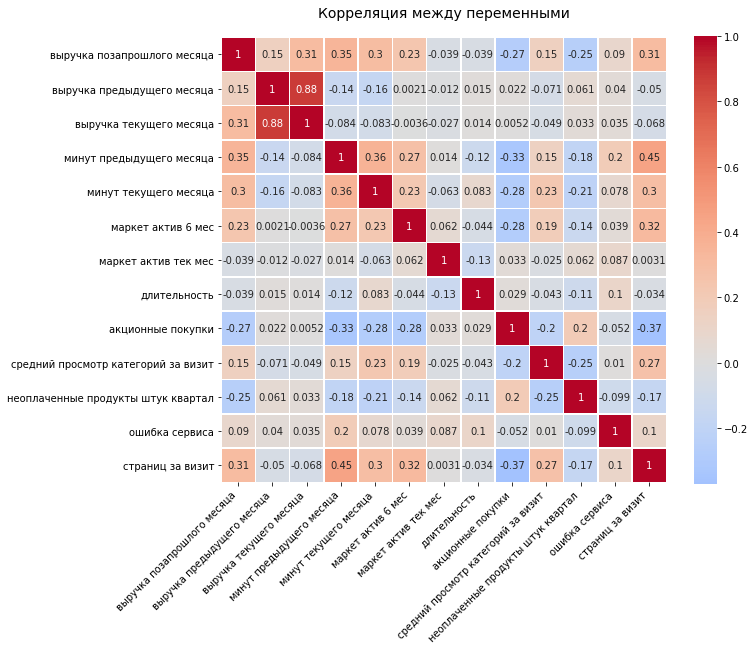

In [ ]:
fig, ax = plt.subplots(figsize=(11, 10))

corr_matrix = common_df.corr(method='spearman')

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Корреляция между переменными', 
             fontsize=14, 
             pad=20
)

plt.xticks(rotation=45, 
           ha='right'
)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Наблюдается связь между:  
* Выручка текущего месяца - Выручка предыдущего месяца (0.88) - очень сильная связь; 
* Маркет актив 6 мес - Маркет активн тек мес (0.62) - сильная связь;  

Наблюдается отрицательная корреляция:  
* Ошибки сервиса - Страницы за визит (-0.37)  
* Ошибки сервиса - Активные покупки (-0.37)  
* Неоплаченные продукты штук квартал - Ошибки сервиса (0.1)  
* Длительность - Ошибки сервиса (-0.13)  
Как видим, ошибки отрицательно влияют на показатели, имеется зависимость

Создадим матрицу корреляций phik:

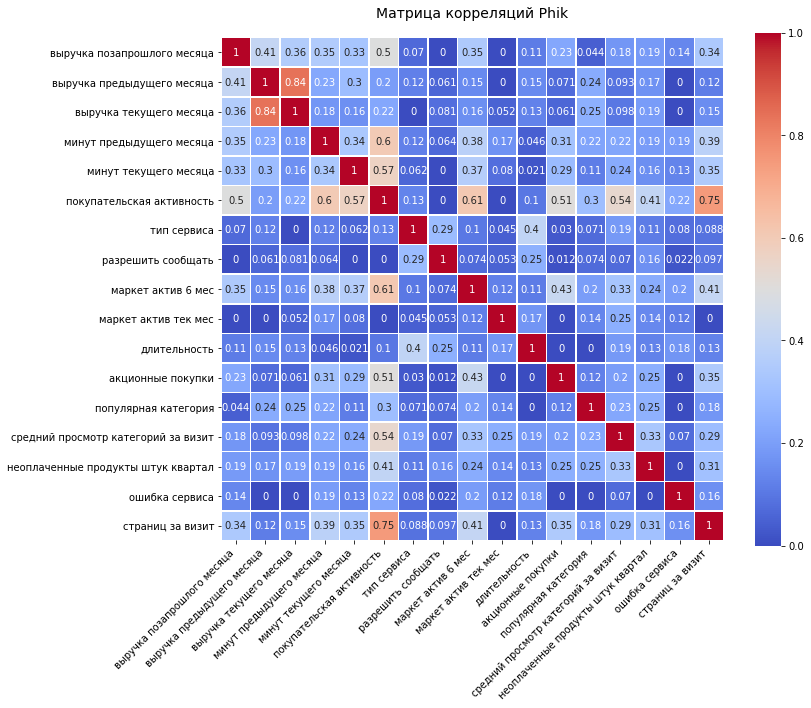

In [ ]:
fig, ax = plt.subplots(figsize=(12, 11))

corr_matrix = phik.phik_matrix(
    common_df, 
    interval_cols=['выручка позапрошлого месяца',
                   'выручка предыдущего месяца', 
                   'выручка текущего месяца',
                   'длительность',
                   'акционные покупки']
)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0.5,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Матрица корреляций Phik', 
             fontsize=14, 
             pad=20
)

plt.xticks(rotation=45, 
           ha='right'
)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Наблюдается связь между:  

* Покупательская активность - Страниц за визит (0.75)  
* Выручка пред.мес - Выручка тек.мес (0.84)
* Покупательская активность - Минут пред.мес (0.60)
* Покупательская активность - Маркет актив 6 мес (0.61)
* Маркет актив 6 мес - Акционные покупки (0.43)

**Наблюдается мультиколлинеарность.**

~**Устраним мультиколлинеарность:**~

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 5. Корреляционный анализ
    </span>
</span>

Для выявления корреляций использовали две матрицы - Спирмана и Phik. В ходе анализа была выявлена сильная связь между некоторыми признаками.  

~Устранена мультиколлинеарность при помощи удаления некоторых признаков.~    

Несмотря на высокую корреляцию между показателями, некоторые из них могут быть важными для компании.  
Так, под удаление у нас попали показатели 'маркет актив 6 мес' и 'выручка предыдущего месяца'. Это те показатели, которые могут помочь нам отслеживать динамику в том или ином виде, дадут более ясное видение по закономерностям.  Не трогаем.

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 6. Использование пайплайнов
    </span>
</span>

На данном этапе необходимо применить все изученные ранее модели, используя пайплайны.  
За основу возьмем один общий пайплайн для моделей.

Подготовим данные

In [ ]:
# кодируем целевой признак:
X = common_df.drop(['покупательская активность'], axis=1)
y = common_df['покупательская активность']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=RANDOM_STATE,
    stratify = y
)

display(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

le = LabelEncoder()
le.fit_transform(y_train.unique())
print ('Значениям', le.classes_, 'назначено соответственно', le.transform(le.classes_))
y_train = le.transform(y_train)
y_test = le.transform(y_test)

(972, 16)

(324, 16)

(972,)

(324,)

Значениям ['прежний уровень' 'снизилась'] назначено соответственно [0 1]


In [ ]:
ohe_columns = ['популярная категория']
ord_columns = ['тип сервиса', 'разрешить сообщать']

In [ ]:
common_df.head(1)

,выручка позапрошлого месяца,выручка предыдущего месяца,выручка текущего месяца,минут предыдущего месяца,минут текущего месяца,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
id,,,,,,,,,,,,,,,,,
215349,4472.0,4971.6,5216.0,12,10,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5


In [ ]:
num_columns = [
    'выручка позапрошлого месяца',
    'выручка предыдущего месяца',
    'выручка текущего месяца',          
    'минут предыдущего месяца',            
    'минут текущего месяца',               
    'маркет актив 6 мес',
    'маркет актив тек мес',
    'длительность',                        
    'акционные покупки',                   
    'средний просмотр категорий за визит',
    'неоплаченные продукты штук квартал',  
    'ошибка сервиса',
    'страниц за визит'
]

In [ ]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))
    ]
    )

In [ ]:
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум'],
                    ['да', 'нет'],
                    
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

<div style="background-color: #F5F5DC; text-align: center; padding: 12px; border-radius: 10px;">
    <span style="font-weight: bold; font-size: 20px; color: #333;">
        Обучение моделей  KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC()
    </span>
</div>

Для сравнения качества моделей возьмем за основу метрику ROC AUC - универсальная метрика, показывающая способность модели различать классы.  
Кривая ROC отображает зависимость True Positive Rate (TPR) от False Positive Rate (FPR) при различных порогах классификации. AUC — площадь под этой кривой, агрегированный показатель качества модели.

In [ ]:
# создаём итоговый пайплайн
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', KNeighborsClassifier())
])

param_grid = [
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(1, 800),
        'models__max_features': range(1, 30),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['poly', 'rbf', 'sigmoid'],
        'models__degree': range(1, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
    }
]

model = RandomizedSearchCV(
                                pipe_final,
                                param_grid, 
                                cv=5,
                                scoring='roc_auc',
                                random_state=RANDOM_STATE,
                                n_jobs=-1
).fit(X_train, y_train)

# Отобразим графически результаты в виде таблицы:
summary_data = [
    ['Модель', type(model.best_estimator_['models']).__name__],
    ['ROC-AUC (кросс-валидация)', f'{model.best_score_:.4f}'],
    ['Параметры модели', '']
]


for param, value in sorted(model.best_params_.items()):
    if param.startswith('models__'):
        param_name = param.replace('models__', '')
        summary_data.append([f'  {param_name}', str(value)])

summary_data.append(['Препроцессинг', ''])
preproc_value = model.best_params_.get('preprocessor__num', 'passthrough')
preproc_name = preproc_value if isinstance(preproc_value, str) else type(preproc_value).__name__
summary_data.append(['  Числовые признаки', preproc_name])

# Данные модели:
print('\n' + '='*60)
print('РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МОДЕЛИ'.center(60))
print('='*60)
print(tabulate(summary_data, headers=['Характеристика', 'Значение'], tablefmt='grid'))
print('='*60)


               РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МОДЕЛИ                
+---------------------------+--------------+
| Характеристика            | Значение     |
+===========================+==============+
| Модель                    | SVC          |
+---------------------------+--------------+
| ROC-AUC (кросс-валидация) | 0.8405       |
+---------------------------+--------------+
| Параметры модели          |              |
+---------------------------+--------------+
| degree                    | 9            |
+---------------------------+--------------+
| kernel                    | sigmoid      |
+---------------------------+--------------+
| Препроцессинг             |              |
+---------------------------+--------------+
| Числовые признаки         | RobustScaler |
+---------------------------+--------------+


Таким образом, мы получили параметры лучшей модели.

Оценим производительность на независимой тестовой выборке:

In [ ]:
y_test_pred_proba = model.best_estimator_.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print('\n' + '='*60)
print('Тестирование на независимой выборке'.center(60))
print('='*60)

comparison_data = [
    ['Кросс-валидация (train)', f'{model.best_score_:.4f}'],
    ['Тестовая выборка (test)', f'{test_roc_auc:.4f}'],
    ['Разница (train - test)', f'{(model.best_score_ - test_roc_auc):.4f}']
]

print(tabulate(comparison_data, headers=['Метрика', 'ROC-AUC'], tablefmt='grid'))

diff = abs(model.best_score_ - test_roc_auc)
print(f'\n Анализ Разницы:')
if diff < 0.02:
    print(f' Отличная обобщающая способность, разница < 0.02')
elif diff < 0.05:
    print(f' Хорошая обобщающая способность, разница < 0.05')
else:
    print(f' Возможное переобучение, разница ≥ 0.05')

print(f'\n Итоговое качество модели:')
if test_roc_auc > 0.9:
    print(f' ОТЛИЧНОЕ качество модели, AUC > 0.9')
elif test_roc_auc > 0.8:
    print(f' ХОРОШЕЕ качество модели, AUC > 0.8')
elif test_roc_auc > 0.7:
    print(f' ПРИЕМЛЕМОЕ качество, AUC > 0.7')
else:
    print(f' ТРЕБУЕТСЯ доработка модели, AUC ≤ 0.7')


            Тестирование на независимой выборке             
+-------------------------+-----------+
| Метрика                 |   ROC-AUC |
+=========================+===========+
| Кросс-валидация (train) |    0.8405 |
+-------------------------+-----------+
| Тестовая выборка (test) |    0.8433 |
+-------------------------+-----------+
| Разница (train - test)  |   -0.0027 |
+-------------------------+-----------+

 Анализ Разницы:
 Отличная обобщающая способность, разница < 0.02

 Итоговое качество модели:
 ХОРОШЕЕ качество модели, AUC > 0.8


* Визуализируем ROC-кривую:

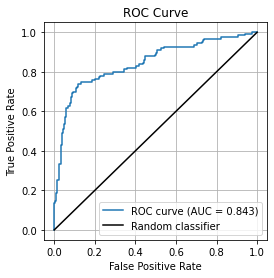

Хорошее качество модели


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k-', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

if test_roc_auc > 0.9:
    print('Отличное качество модели')
elif test_roc_auc > 0.8:
    print('Хорошее качество модели')
elif test_roc_auc > 0.7:
    print('Приемлемое качество')
else:
    print('Требуется доработка модели')

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 6. Использование пайплайнов
    </span>
</span>

Нами был использован единый пайплайн для четырех моделей.  
По результатам исследований, лучшая модель имеет следующие параметры:  
  
  SVC  
degree=9  
kernel='sigmoid',   
probability=True,   
random_state=42.   

Хорошее качество модели:  
ROC-AUC на кросс-валидации: 0.8405  
ROC-AUC на тестовой выборке: 0.8433

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 7.   Анализ важности признаков
    </span>
</span>

На данном этапе необходимо оценить важность признаков для лучшей модели и постройте график важности с помощью метода SHAP, сделать выводы.

In [ ]:
best_model = model.best_estimator_
best_preprocessor = model.best_estimator_.named_steps['preprocessor']

X_train_trans = pd.DataFrame(best_preprocessor.transform(X_train), 
                             columns=best_preprocessor.get_feature_names_out())

X_train_trans = X_train_trans.sample(frac=0.1, 
                                     replace=True, 
                                     random_state=42)

X_test_trans = pd.DataFrame(best_preprocessor.transform(X_test), 
                            columns=best_preprocessor.get_feature_names_out())

X_test_trans = X_test_trans.sample(frac=0.1, 
                                   replace=True, 
                                   random_state=42)

explainer = shap.KernelExplainer(best_model.named_steps['models'].predict, 
                                 X_train_trans)

shap_values = explainer.shap_values(X_test_trans, 
                                    nsamples=100, 
                                    random_state=RANDOM_STATE)

  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
best_model = model.best_estimator_
best_preprocessor = model.best_estimator_.named_steps['preprocessor']

X_train_trans = pd.DataFrame(best_preprocessor.transform(X_train), 
                             columns=best_preprocessor.get_feature_names_out())

X_test_trans = pd.DataFrame(best_preprocessor.transform(X_test), 
                            columns=best_preprocessor.get_feature_names_out())

explainer = shap.SamplingExplainer(best_model.named_steps['models'].predict, 
                                   X_train_trans)
shap_values = explainer.shap_values(X_test_trans, 
                                    nsamples=100, 
                                    random_state=RANDOM_STATE)

  0%|          | 0/324 [00:00<?, ?it/s]

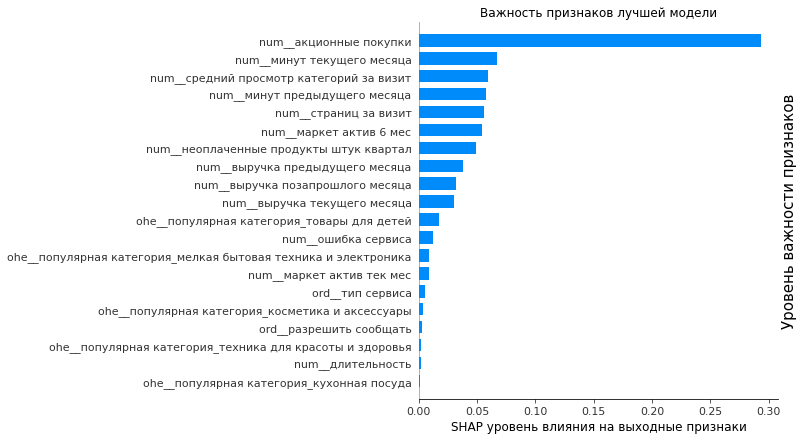

In [ ]:
shap.initjs()
shap.summary_plot(shap_values, 
                  X_test_trans, 
                  plot_type='bar',
                  plot_size=(12, 6),
                  show=False)

fig, ax = plt.gcf(), plt.gca()
ax.tick_params(labelsize=11)
ax.set_xlabel('SHAP уровень влияния на выходные признаки', 
              fontsize=12)
ax.set_title('Важность признаков лучшей модели', 
             fontsize=12)
cb_ax = fig.axes[0] 
cb_ax.tick_params(labelsize=11)
cb_ax.yaxis.set_label_position('right')
cb_ax.set_ylabel('Уровень важности признаков', 
                 fontsize=15)
plt.show();

<span style="background-color: #FFDEAD; text-align: center; padding: 6px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 18px; color: black;">
        Выводы по Этап 7. Анализ важности признаков
    </span>
</span>

Нами был использован единый пайплайн.  
По результатам исследований была выбрана лучшая модель, которая показывает следующие результаты:  
ROC-AUC на кросс-валидации: 0.8405  
ROC-AUC на тестовой выборке: 0.8433  

Наша модель хорошо работает на данных, на которых обучалась и на совершенно новых данных, которых никогда не видела.  

Основные важные признаки модели, отобранные по методу SHAP:  
* Акционные покупки - cамый значимый фактор;  
* Минуты текущего месяца - активность клиента прямо сейчас;  
* Средний просмотр категорий за визит - глубина интереса;  
* Страниц за визит - характеризует вовлеченность в процессе;  


Основную предсказательную силу модели обеспечивают признаки, связанные с активностью пользователя и его покупательским поведением.  
Категории товаров и некоторые сервисные признаки практически не вносят вклада в предсказания модели.

Таким образом, модель хорошо объясняет, какие именно действия и характеристики пользователя наиболее сильно влияют на целевой результат, и позволяет сфокусировать усилия на самых эффективных способах воздействия, что в дальнейшем помогает компаниям выстраивать стратегию по достижению тех или иных целей, решению задач.  
Например, создавать персональные предложения, создавать группы риска и т.п.  

<span style="background-color: #87CEFA; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Этап 8.   Сегментация покупателей
    </span>
</span>

Необходимо выполнить сегментацию покупателей.  
Использовать результаты моделирования и данные о прибыльности покупателей.  
Выбрать группу покупателей и предложить, как увеличить её покупательскую активность

Исходя из свойств нормального распределения, значения, которые находятся в пределах одного стандартного отклонения от медианы , считаются нормальными. 68,2% данных лежат в пределах +/-1

Значения, выходящие за эти границы, интерпретируются следующим образом:  
Ниже этого диапазона — низкий уровень (примерно 15,9% данных).  
Выше этого диапазона — высокий уровень (также примерно 15,9% данных).  
  
Указанные процентные соотношения являются теоретической моделью. Мы применяем именно её, так как в рамках проекта нет возможности получить от заказчика уточнённые или фактические пороговые значения.

Рассчитаем стандартное отклонение для параметра 'прибыль':

In [ ]:
median_profit = money['прибыль'].median()
sko = np.std(money['прибыль'])

In [ ]:
print('Медиана прибыли: ', median_profit)
print('Стандартное отклонение : ', sko)

Медиана прибыли:  4.045
Стандартное отклонение :  1.0133321434255445


In [ ]:
money['прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

Реализуем функцию предсказания:

In [ ]:
def custom_predict(X, threshold):
    probs = best_model.predict_proba(X) 
    return (probs[:, 1] > threshold).astype(int)

Выставим порог 0.5

In [ ]:
# предсказание на данных с выбранным порогом
predictions_precision = custom_predict(X, threshold=0.5)

In [ ]:
X['predictions'] = predictions_precision
X['probs'] = best_model.predict_proba(X)[:,1]

In [ ]:
def categorize_profit(value, median_val, std_val):
    
    if value < (median_val - std_val):
        return 'мало'
    if value > (median_val + std_val):
        return 'много'
    return 'нормально'

money['категории прибыли'] = money['прибыль'].apply(
    lambda x: categorize_profit(x, median_profit, sko)
)

In [ ]:
X = X.reset_index()

In [ ]:
X = pd.merge(X, money, on='id', sort=True)
X.head(2)

,id,выручка позапрошлого месяца,выручка предыдущего месяца,выручка текущего месяца,минут предыдущего месяца,минут текущего месяца,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,predictions,probs,прибыль,категории прибыли
0,215349,4472.0,4971.6,5216.0,12,10,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,1,0.743588,4.16,нормально
1,215350,4826.0,5058.4,5457.5,8,13,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,0,0.102512,3.13,нормально


Визуализируем вероятности снижения покупательской активности и распределение порога предсказаний:

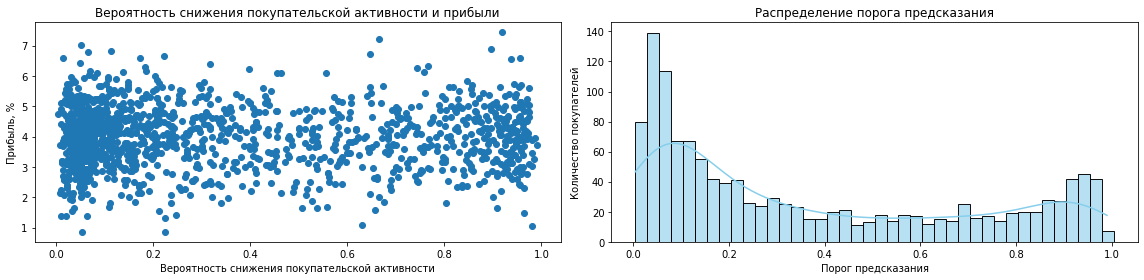

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# диаграмма рассеяния
axes[0].scatter(X.probs, X.прибыль)
axes[0].set_title('Вероятность снижения покупательской активности и прибыли')
axes[0].set_xlabel('Вероятность снижения покупательской активности')
axes[0].set_ylabel('Прибыль, %')

# гистограмма порога предсказания
sns.histplot(data=X, 
             x='probs', 
             binwidth=0.025, 
             kde=True,
             ax=axes[1],
             stat='count', 
             alpha=0.6, 
             color='skyblue', 
             edgecolor='black')

axes[1].set_title('Распределение порога предсказания')
axes[1].set_xlabel('Порог предсказания')
axes[1].set_ylabel('Количество покупателей')

plt.tight_layout()
plt.show()

Модель выдает вероятности оттока для клиентов с разным уровнем прибыли. Она не просто предсказывает отток "плохих" клиентов, а способна выявлять угрозу потери даже для клиентов с высокой прибылью.  

В правой части графика с высокой вероятностью оттока есть точки с прибылью 5-7%. Это критически важные клиенты, которых нужно удерживать в первую очередь.  

В левой части с низкой вероятностью оттока также есть клиенты с низкой прибылью  ~1-2%, что говорит о том, что они не представляют большой ценности, но и не уходят.  

Распределение имеет бимодальный характер:
Первый пик в левой части: большое количество клиентов - более 130 имеют очень низкую вероятность оттока, ближе к 0.0 — 0.1.  
Второй пик в правой части наблюдается в районе 0.8 — 1.0, где находится около 40-50 клиентов с очень высокой вероятностью оттока.  
Между этими пиками (в районе 0.2 — 0.7) наблюдается "провал" — мало клиентов с промежуточными вероятностями.

Для клиентов, у которых снижается покупательская активность, проводят кампанию по рассылке персональных предложений.

Поработаем с клиентами точечно, установим порог в 0.85 - это даст нам более точную классификацию, уменьшив ложные срабатывания.
Акцент на наиболее рисковых клиентов.

In [ ]:
X['категория снижения'] = X['probs'].apply(
    lambda x: 'Снизилась' if x > 0.85 else 'Прежний уровень')                          

In [ ]:
X.head(2)

,id,выручка позапрошлого месяца,выручка предыдущего месяца,выручка текущего месяца,минут предыдущего месяца,минут текущего месяца,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,predictions,probs,прибыль,категории прибыли,категория снижения
0,215349,4472.0,4971.6,5216.0,12,10,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,1,0.743588,4.16,нормально,Прежний уровень
1,215350,4826.0,5058.4,5457.5,8,13,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,0,0.102512,3.13,нормально,Прежний уровень


В рамках аналитического исследования мы сфокусируемся на сегменте клиентов с низкой доходностью, демонстрирующих высокую вероятность снижения покупательской активности. Эта группа представляет наибольший операционный риск и требует детального изучения.  

Для формирования контрольного результата мы сохраним группу клиентов с сохранённым уровнем активности. Данный сегмент будет служить ориентиром, позволяя оценить целевые метрики и выявить отклонения в проблемной группе.

Визуализируем:

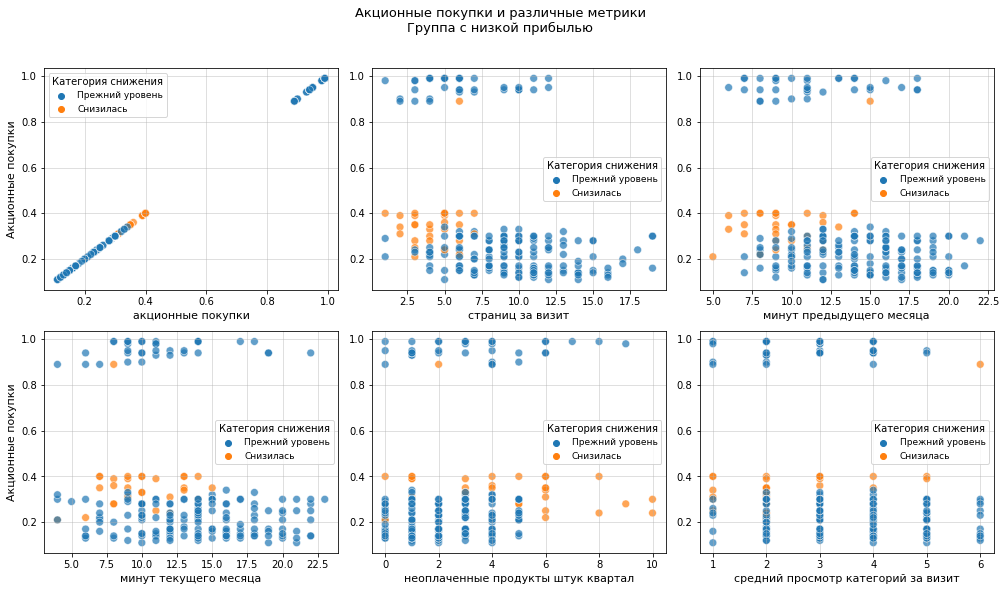

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

x_vars = [
    'акционные покупки',
    'страниц за визит',
    'минут предыдущего месяца',
    'минут текущего месяца',
    'неоплаченные продукты штук квартал',
    'средний просмотр категорий за визит'
]

filtered_data = X.query('`категории прибыли` == "мало"')

for idx, x_var in enumerate(x_vars):
    ax = axes[idx]
    
    
    sns.scatterplot(data=filtered_data, 
                    x=x_var, 
                    y='акционные покупки', 
                    hue='категория снижения', 
                    alpha=0.7, 
                    s=60, 
                    ax=ax)
    
   
    ax.set_xlabel(x_var, 
                  fontsize=11)
    
    if idx in [0, 3]:
        ax.set_ylabel('Акционные покупки', fontsize=11)
    else:
        ax.set_ylabel('')
    
    ax.legend(title='Категория снижения', 
              fontsize=9, 
              title_fontsize=10)
    
    ax.grid(True, 
            alpha=0.5, 
            linestyle='-')

for idx in range(len(x_vars), 6):
    fig.delaxes(axes[idx])

plt.suptitle('Акционные покупки и различные метрики\n'
             'Группа с низкой прибылью', 
             fontsize=13, 
             y=1.02)
plt.tight_layout()
plt.show()

* **диаграмма 1: акционные покупки - акционные покупки:**  
Клиенты с низкой долей акционных покупок чаще всего сохраняют прежний уровень прибыли.  
Клиенты с высокой долей акционных покупок чаще всего снижают прибыль.  
  
  Получается, что чем выше доля акционных покупок, тем выше вероятность снижения прибыли. Акционные покупки могут быть индикатором клиента, который не готов платить полную цену и может легко уйти к конкурентам.  

* **диаграмма 2: акционные покупки - страниц за визит:**  
Клиенты, которые просматривают мало страниц за визит и при этом делают много акционных покупок, находятся в зоне риска снижения прибыли.   
Возможно, они быстро находят нужный товар по акции и уходят, не исследуя другие продукты.  

* **диаграмма 3: акционные покупки - минут предыдущего месяца:**  
Если клиент проводит много времени на сайте, но при этом его покупки преимущественно акционные, это может сигнализировать о снижении прибыльности.  

* **диаграмма 4: акционные покупки - минут текущего месяца:**  
Оранжевые точки категории Снизилась склонны к более высоким значениям акционных покупок и умеренному времени на сайте.
Есть также группа оранжевых точек с очень низким временем менее 5 минут, что указывает на клиентов, делающих только акционные покупки.  

* **диаграмма 5: акционные покупки - неоплаченные продукты штук квартал:**  
При низком количестве неоплаченных товаров 0-2 преобладают синие точки стабильной прибыли.  
При увеличении числа неоплаченных товаров 3-8 появляется больше оранжевых точек, особенно при высокой доле акционных покупок.  
При очень большом числе неоплаченных товаров >8 снова появляются синие точки — возможно, это клиенты, которые часто добавляют в корзину, но редко покупают, и их прибыльность не меняется, так как они не совершают покупок вообще.  

Клиенты, часто оставляющие товары в корзине и при этом делают много акционных покупок — это высокий риск снижения прибыли. Возможно, они неудовлетворены условиями покупки или ищут лучшие предложения.

* **диаграмма 6: акционные покупки - средний просмотр категорий за визит:**  
Клиенты, которые просматривают мало категорий, вероятно, целенаправленно ищут конкретный товар по акции, и при этом делают много акционных покупок, находятся в зоне риска. Они менее вовлечены в общую продукцию магазина.  

**Вывод:**  
Акционные покупки — главный маркер риска. Чем выше доля акционных покупок, тем выше вероятность снижения прибыли. Это говорит о том, что такие клиенты: ориентируются только на цену, сильнее склонны к оттоку.  

Клиенты, которые: просматривают мало страниц и категорий, проводят мало времени на сайте, часто оставляют товары в корзине и при этом делают акционные покупки — являются самой неблагоприятной, с точки зрения прибыли, для компании группой.
Длительное время на сайте не гарантирует прибыль. Даже если клиент проводит много времени, но его поведение сводится к поиску акций, он может стать "неэффективным".  

**Рекомендации:**  
персонализировать маркетинговые кампании: предлагать персональные скидки на товары вне акций, чтобы повысить их лояльность. Использовать рекомендательные системы, чтобы показать им новые категории и увеличить глубину просмотра.

Сегментируем группу клиентов, у которых количество купленных акционных товаров не более 30%.

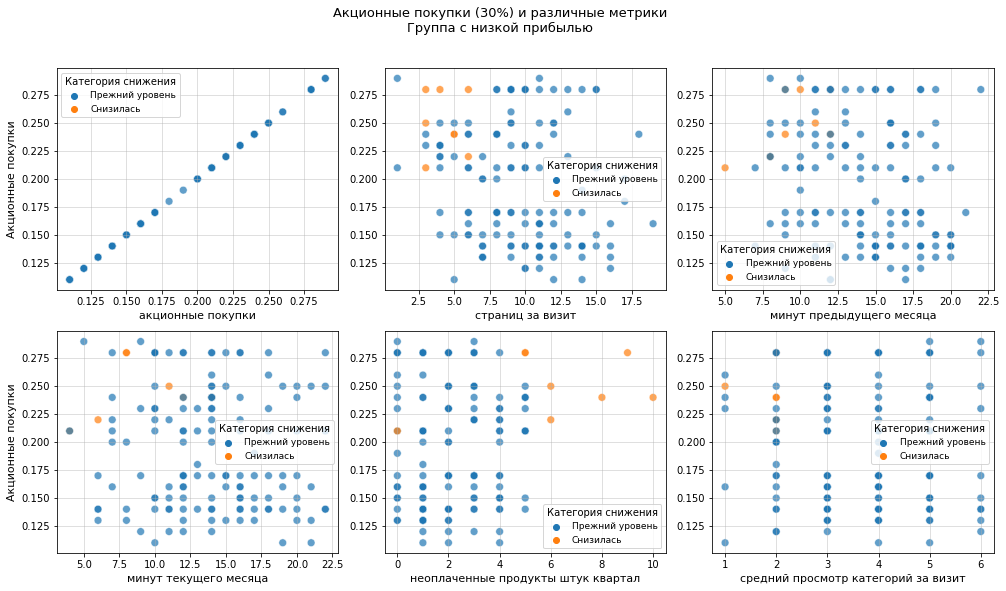

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

x_vars = [
    'акционные покупки',
    'страниц за визит',
    'минут предыдущего месяца',
    'минут текущего месяца',
    'неоплаченные продукты штук квартал',
    'средний просмотр категорий за визит'
]

filtered_data = X.query('`категории прибыли` == "мало" & `акционные покупки` < 0.3')

for idx, x_var in enumerate(x_vars):
    ax = axes[idx]
    
    sns.scatterplot(data=filtered_data, 
                    x=x_var, 
                    y='акционные покупки', 
                    hue='категория снижения', 
                    alpha=0.7, 
                    s=60, 
                    ax=ax)
    
    ax.set_xlabel(x_var, 
                  fontsize=11)
    
    if idx in [0, 3]:
        ax.set_ylabel('Акционные покупки', fontsize=11)
    else:
        ax.set_ylabel('')
    
    ax.legend(title='Категория снижения', 
              fontsize=9, 
              title_fontsize=10)
    
    ax.grid(True, 
            alpha=0.5, 
            linestyle='-')

for idx in range(len(x_vars), 6):
    fig.delaxes(axes[idx])

plt.suptitle('Акционные покупки (30%) и различные метрики\n'
             'Группа с низкой прибылью', 
             fontsize=13, 
             y=1.02)
plt.tight_layout()
plt.show()

Данные на этих графиках теперь относятся только к клиентам, у которых количество акционных покупок  меньше 30% и которые геренируют прибыль по категории "мало".

* **диаграмма 1: акционные покупки - акционные покупки:**  
Оранжевые точки концентрируются в правой части этого диапазона — то есть у тех, кто делает более 30% акционных покупок, прибыль чаще снижается.  
Синие точки — в левой и центральной части 0.125–0.275.  
Вывод: Порог, после которого начинается риск снижения прибыли, смещается вверх > ~0.30. 

* **диаграмма 2: акционные покупки - страниц за визит:**  
У клиентов с низкой долей акционных покупок те, кто просматривает менее 5 страниц за визит, чаще всего теряют прибыль оранжевые точки.  
Те, кто просматривает 7–15 страниц, чаще сохраняют прибыль.  
Просмотра остается ключевым фактором удержания. Даже в этой расширенной группе клиенты, которые исследуют сайт, более стабильны.  

* **диаграмма 3: акционные покупки - минут предыдущего месяца:**  
У клиентов с низкой активностью в прошлом месяце (<5 минут) преобладают оранжевые точки, особенно при доле акционных покупок >0.30.
В то же время, синие точки сосредоточены в диапазоне 10–20 минут.  
При этом даже среди клиентов с высокой активностью 15–20 мин есть оранжевые точки — но только если их доля акционных покупок близка к верхней границе  ~0.35.

* **диаграмма 4: акционные покупки - минут текущего месяца:**  
Почти нет оранжевых точек при текущей активности выше 10–12 минут, даже если доля акционных покупок близка к 0.3.
Показатели стабильной прибыли преобладают в диапазоне 8–20 минут, в центре.

* **диаграмма 5: акционные покупки - неоплаченные продукты за квартал:**  
Клиенты, которые оставляют товары в корзине, особенно 6–10 штук, чаще всего теряют прибыльность.
Синие точки сосредоточены при 0–4 неоплаченных товарах. 

* **диаграмма 6: акционные покупки - средний просмотр категорий за визит:**  
Клиенты, которые почти не используют акции, но просматривают мало категорий — это потенциальные потерянные клиенты. Они не исследуют ассортимент, что говорит о потере интереса.  

**Вывод:**  
Даже 1-2 акционные покупки — это сигнал. 
Основная угроза — потеря вовлеченности: малое время на сайте, мало просмотренных страниц и категорий.
Неоплаченные товары — выступают маркером, даже если клиент не использует акции.

**Рекомендации:**  
* Персонализированные email, sms, уведомления в приложении/сайте с подборками товаров. Нужно быть аккуратным: кто-то мог не давать разрешения на рекламу.  
* Внедрить напоминания о товарах в корзине.  
* Возможная переработка дизайна приложения/сайта для упрощения процедуры оформления заказа.

Предлагаю посмотреть:

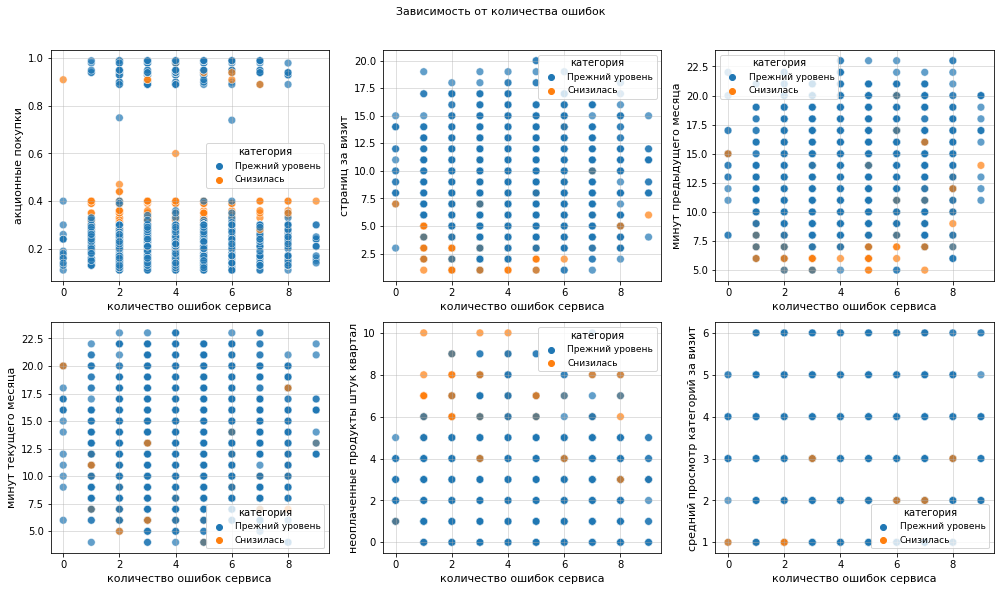

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

x_var = 'ошибка сервиса'

y_vars = [
    'акционные покупки',
    'страниц за визит',
    'минут предыдущего месяца',
    'минут текущего месяца',
    'неоплаченные продукты штук квартал',
    'средний просмотр категорий за визит'
]


filtered_data = X.copy()

for idx, y_var in enumerate(y_vars):
    ax = axes[idx]
    
    sns.scatterplot(
        data=filtered_data,
        x='ошибка сервиса',
        y=y_var,
        hue='категория снижения',
        alpha=0.7,
        s=60,
        ax=ax
    )
    
    ax.set_xlabel('количество ошибок сервиса', 
                  fontsize=11
    )
    
    ax.set_ylabel(y_var, 
                  fontsize=11
    )
    
    ax.legend(
        title='категория',
        fontsize=9,
        title_fontsize=10
    )
    
    ax.grid(True, alpha=0.5)

for idx in range(len(y_vars), 6):
    fig.delaxes(axes[idx])

plt.suptitle(
    'Зависимость от количества ошибок',
    fontsize=11,
    y=1.02
)

plt.tight_layout()
plt.show()

**1. акционные покупки - ошибки сервиса:**  
При увеличении количества ошибок у пользователей из категории «снизилась» значения чаще находятся на более низких уровнях;
Доля акционных покупок встречается реже.  

**2. страниц за визит - ошибки сервиса:**  
С увеличением количества ошибок пользователи с падением показателей чаще концентрируются в зоне меньшего числа просмотренных страниц.

**3. минут предыдущего месяца - ошибки сервиса:**  
При росте ошибок пользователи из группы «снизилась» чаще демонстрируют меньшую вовлечённость.  

**4. минут текущего месяца - ошибки сервиса:**  
практически та же картина, что и в п.3 предыдущего месяца

**5. неоплаченные продукты за квартал - ошибки сервиса:**  
При увеличении количества ошибок растёт плотность точек с большим числом неоплаченных товаров;

**6. средний просмотр категорий за визит - ошибки сервиса:**  
При увеличении числа ошибок покупатели реже просматривают меньше категорий товаров;

Ошибки сайт выдает. Так или иначе влияние на результаты оказывают. Пусть и не катастрофические. Но если смотреть глобально, то это может влиять на дальнейшую лояльность.  
Нет гарантии, что ошибок не будет становиться больше. К тому же, эффект "сарафанного радио" никто не отменял. В наш век диджитализации и скорости, некоторые ошибки могут привести к финансовым потерям, репутационным.  
Но это если сильно углубляться и развивать все это.

<span style="background-color: #008000; text-align: center; padding: 10px; border-radius: 10px; display: inline-block;">
    <span style="font-weight: bold; font-size: 24px; color: white;">
        Итоговый вывод по проекту
    </span>
</span>

Целью проекта было создание модели для персонализации предложений постоянным клиентам с целью увеличения их покупательской активности и, как следствие, повышения дохода компании. Для этого необходимо было:

* построить модель, предсказывающую вероятность снижения покупательской активности клиента в следующие три месяца;  
* включить данные о прибыльности клиентов;  
* сегментировать покупателей и разработать персонализированные предложения;

В проекте использовались четыре датасета, содержащих различную информацию по покупательской активности.  

Проведенная предобработка включала:  

* приведение названий столбцов к нижнему регистру;  
* замена подчеркиваний на пробелы;  
* исправление неявных дубликатов и орфографических ошибок;  
* проверка на дубликаты.

Для поиска оптимальной модели были выполнены следующие шаги:  
* объединение таблиц для получения полной картины по каждому клиенту;  
* проведение исследовательского и корреляционного анализа данных;  
* создание пайплайна;

Было выполнено сравнение нескольких моделей:

* логистическая регрессия;
* KNN;  
* дерево решений;  
* SVM.

По итогу лучшая модель имеет следующие характеристики:  
SVC  
degree=9  
kernel='sigmoid',  
probability=True,  
random_state=42.  
  
Хорошее качество модели:  
ROC-AUC на кросс-валидации: 0.8405  
ROC-AUC на тестовой выборке: 0.8433

На основе модели и данных о прибыльности клиенты были сегментированы на группы:  
  
* Сегмент 1: Клиенты с низкой прибыльностью;  
* Сегмент 2: Клиенты с низкой прибыльностью и долей акционных покупок 30%.

Общие рекомендации для сегментов:  


* Персонализированные email, sms, уведомления в приложении/сайте с подборками товаров. Нужно быть аккуратным: кто-то мог не давать разрешения на рекламу.  
* Внедрение напоминания о товарах в корзине;  
* Возможная переработка дизайна приложения/сайта для упрощения процедуры оформления заказа;  
* Искоренение причин сбоев при оформлении заказов;  

Проект выполнен: построена модель для предсказания снижения покупательской активности, проведена сегментация клиентов и разработаны персонализированные предложения. Реализация этих рекомендаций позволит компании увеличить удержание клиентов и повысить доход.

https://github.com/Osipov-Sergey/Supervised-Learning